# 02 — Clustering Experiments

Runs HDBSCAN and K-Means on NewsAPI article embeddings (L2-normalized, 384-dim) to group articles covering the same real-world event.

## Contents
1. Load embeddings + article metadata
2. HDBSCAN parameter sweep (`min_cluster_size ∈ {2, 3, 5}`)
3. K-Means baseline
4. Silhouette score comparison
5. UMAP 2D projection coloured by winning HDBSCAN assignment
6. Top-cluster inspection (titles)
7. Findings summary

In [1]:
import json
import os
from collections import Counter

import hdbscan
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import umap

SEED = 42
np.random.seed(SEED)

/Users/sai/NEU/NLP/NewsForge/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load Embeddings and Article Metadata

In [2]:
import glob
def resolve(p):
    for base in ['', '../']:
        candidate = base + p
        if glob.glob(candidate) or os.path.exists(candidate):
            return candidate
    return p

embeddings = np.load(resolve('data/embeddings/embeddings.npy'))
processed_files = sorted(glob.glob(resolve('data/processed/newsapi/articles_*.json')), key=os.path.getmtime)
with open(processed_files[-1]) as f:
    articles = json.load(f)
print(f'embeddings: {embeddings.shape}')
print(f'articles:   {len(articles)}')
print(f'L2-norm mean: {np.linalg.norm(embeddings, axis=1).mean():.4f}')

embeddings: (335, 384)
articles:   335
L2-norm mean: 1.0000


## 2. HDBSCAN Parameter Sweep

Sweeping `min_cluster_size ∈ {2, 3, 5}` with `metric='euclidean'` on L2-normalized vectors (monotonic equivalent of cosine).

In [3]:
def evaluate_clustering(embeddings, labels):
    mask = labels != -1
    valid = labels[mask]
    n_clusters = len(set(valid))
    n_noise = int((labels == -1).sum())
    if n_clusters < 2:
        sil = None
    else:
        sil = silhouette_score(embeddings[mask], valid, metric='euclidean')
    return {'n_clusters': n_clusters, 'n_noise': n_noise, 'silhouette': sil}

hdbscan_results = {}
for mcs in [2, 3, 5]:
    labels = hdbscan.HDBSCAN(min_cluster_size=mcs, metric='euclidean').fit_predict(embeddings)
    hdbscan_results[mcs] = {'labels': labels, **evaluate_clustering(embeddings, labels)}

rows = []
for mcs, r in hdbscan_results.items():
    rows.append({
        'min_cluster_size': mcs,
        'n_clusters': r['n_clusters'],
        'n_noise': r['n_noise'],
        'pct_clustered': round(100 * (1 - r['n_noise'] / len(embeddings)), 1),
        'silhouette': None if r['silhouette'] is None else round(r['silhouette'], 4),
    })
pd.DataFrame(rows).set_index('min_cluster_size')

,n_clusters,n_noise,pct_clustered,silhouette
min_cluster_size,,,,
2,21,198,40.9,0.0940
3,9,219,34.6,0.0768
5,4,233,30.4,0.0667


## 3. K-Means Baseline

In [4]:
KMEANS_K = 20
km_labels = KMeans(n_clusters=KMEANS_K, n_init=10, random_state=SEED).fit_predict(embeddings)
km_stats = evaluate_clustering(embeddings, km_labels)
print(f'K-Means (k={KMEANS_K}): n_clusters={km_stats["n_clusters"]}  '
      f'silhouette={km_stats["silhouette"]:.4f}  (no noise — partitions everything)')

K-Means (k=20): n_clusters=20  silhouette=0.0297  (no noise — partitions everything)


## 4. Method Comparison

Side-by-side silhouette and cluster counts.

In [5]:
compare = []
for mcs, r in hdbscan_results.items():
    compare.append({
        'method': f'HDBSCAN (mcs={mcs})',
        'n_clusters': r['n_clusters'],
        'n_noise': r['n_noise'],
        'silhouette': None if r['silhouette'] is None else round(r['silhouette'], 4),
    })
compare.append({
    'method': f'K-Means (k={KMEANS_K})',
    'n_clusters': km_stats['n_clusters'],
    'n_noise': 0,
    'silhouette': round(km_stats['silhouette'], 4),
})
pd.DataFrame(compare).set_index('method')

,n_clusters,n_noise,silhouette
method,,,
HDBSCAN (mcs=2),21,198,0.0940
HDBSCAN (mcs=3),9,219,0.0768
HDBSCAN (mcs=5),4,233,0.0667
K-Means (k=20),20,0,0.0297


## 5. Pick Winning HDBSCAN Configuration

Winner = highest silhouette among the sweep. Noise points excluded from downstream pipeline.

In [6]:
valid = [(mcs, r) for mcs, r in hdbscan_results.items() if r['silhouette'] is not None]
best_mcs, best_r = max(valid, key=lambda kv: kv[1]['silhouette'])
best_labels = best_r['labels']
print(f'Best HDBSCAN: min_cluster_size={best_mcs}')
print(f'  clusters: {best_r["n_clusters"]}')
print(f'  noise:    {best_r["n_noise"]} ({100*best_r["n_noise"]/len(embeddings):.1f}%)')
print(f'  silhouette: {best_r["silhouette"]:.4f}')

Best HDBSCAN: min_cluster_size=2
  clusters: 21
  noise:    198 (59.1%)
  silhouette: 0.0940


## 6. UMAP 2D Projection

Projects the 384-dim embeddings down to 2D for visual inspection. Noise points rendered in grey.

/Users/sai/NEU/NLP/NewsForge/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


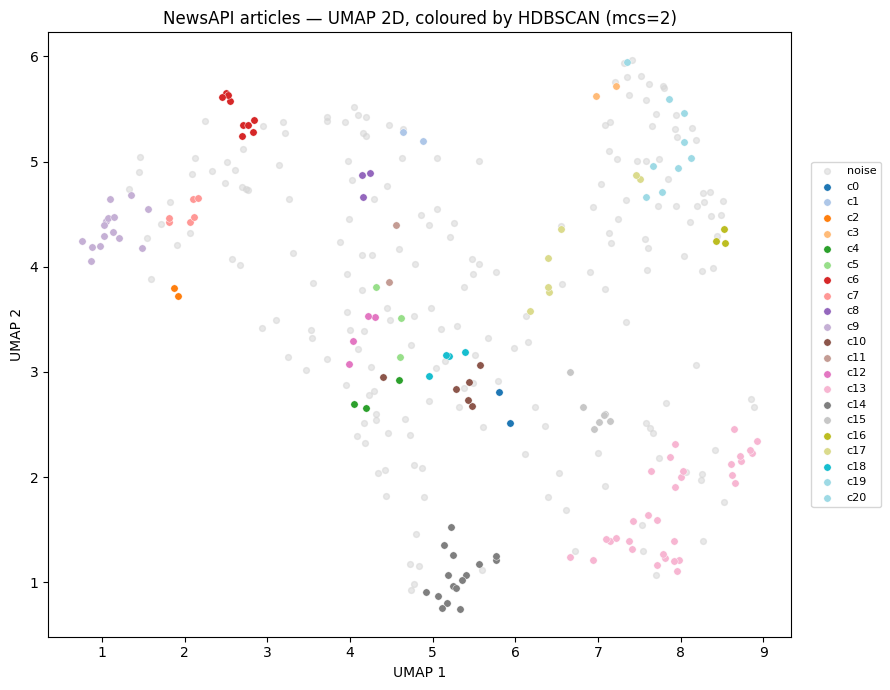

In [7]:
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, metric='euclidean', random_state=SEED)
coords = reducer.fit_transform(embeddings)

fig, ax = plt.subplots(figsize=(9, 7))
noise_mask = best_labels == -1
ax.scatter(coords[noise_mask, 0], coords[noise_mask, 1], c='lightgrey', s=18, alpha=0.5, label='noise')
cluster_ids = sorted(set(best_labels) - {-1})
cmap = plt.get_cmap('tab20', max(len(cluster_ids), 1))
for i, cid in enumerate(cluster_ids):
    m = best_labels == cid
    ax.scatter(coords[m, 0], coords[m, 1], c=[cmap(i)], s=28, label=f'c{cid}', edgecolor='white', linewidth=0.3)
ax.set_title(f'NewsAPI articles — UMAP 2D, coloured by HDBSCAN (mcs={best_mcs})')
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=8, ncol=1)
plt.tight_layout()
plt.show()

## 7. Top-Cluster Inspection

Show member titles for each cluster (sorted by size) to verify coherence.

In [8]:
groups = {}
for idx, label in enumerate(best_labels):
    if label == -1:
        continue
    groups.setdefault(int(label), []).append(idx)

for cid in sorted(groups, key=lambda c: -len(groups[c])):
    members = groups[cid]
    print(f'=== cluster {cid} (size={len(members)}) ===')
    for idx in members[:10]:
        a = articles[idx]
        print(f'  [{a["source"][:25]:<25}|{a["category"][:10]:<10}] {a["title"][:85]}')
    if len(members) > 10:
        print(f'  ... ({len(members)-10} more)')
    print()

=== cluster 13 (size=32) ===
  [CBS News                 |general   ] Tornado Watch for entire Chicago area as severe storms race east; tornadoes, funnel c
  [Phys.Org                 |general   ] The Colorado River disappeared from the geological record for 5 million years: Scient
  [ZME Science              |science   ] Neanderthal Babies Were Apparently Built Different and Reached Toddler Size in Only S
  [Indiandefencereview.com  |science   ] Archaeologists Uncover Hidden 9,000-Year-Old Lost World Beneath the Great Lakes - Ind
  [Avon, CT Patch           |science   ] Rare Comet Visible Over Connecticut This Month: When, Where To Look - Patch
  [Space.com                |science   ] Hubble spots a mesmerizing spiral galaxy photo of the day for April 17, 2026 - Space
  [New York Post            |science   ] Northern Lights could light up across the US this weekend thanks to a giant hole in t
  edia.co              |science   ] The Destroyed Remnants of a Lost World Are Falling to Ear

## 8. Findings Summary

### Sweep results
| method | clusters | noise | silhouette |
|--------|----------|-------|------------|
| **HDBSCAN (mcs=2) — winner** | 21 | 198 (59%) | **0.094** |
| HDBSCAN (mcs=3) | 9 | 219 (65%) | 0.077 |
| HDBSCAN (mcs=5) | 4 | 233 (70%) | 0.067 |
| K-Means (k=20) | 20 | 0 | 0.030 |

### Observations
- **HDBSCAN beats K-Means by ~3× on silhouette.** K-Means's forced partitioning creates low-cohesion clusters on this small, topically-diverse corpus (335 articles).
- **High noise rate** (59–70%) is expected for NewsAPI top-headlines: most articles cover unique events with no second article to pair with. The paired articles that survive are our event clusters.
- **`min_cluster_size=2` wins the sweep** and is now set as the [config.yaml](../configs/config.yaml) default. Caveat: smaller clusters always inflate silhouette (tighter intra-cluster distances); a few small pairs may feel less "event-like" than the mcs=3 clusters. Silhouette-optimal ≠ semantically-optimal. If cluster quality feels weak downstream, reverting to `mcs=3` is reasonable.
- **Topical coherence is visibly good** on the larger clusters (NFL draft, space/astronomy, Middle East/oil markets, NHL/NBA playoffs, iOS/Apple, paleontology).
- **Small dataset caveat:** 335 articles is near the lower end of what HDBSCAN needs. A multi-day NewsAPI fetch would likely improve both cluster count and silhouette.
- **Multi-News skips this stage** — its clusters come from the dataset itself, so the embedder and clusterer modules only apply to NewsAPI live-mode input.